# RobStatTMPY: RobStatTM Python vs R Comparison
**GSoC 2026 | Aakarsh Gupta**

Calls every key RobStatTM function through R (via Rscript subprocess), implements Python equivalents, then compares outputs and figures side by side.

**Functions covered:**
1. `locScaleM` -- robust M-estimators for location and scale (GSOC Test Task 1)
2. `scaleM` -- M-scale estimator and its relationship to `locScaleM` (GSOC Test Task 2)
3. `lmrobdetMM` -- robust MM-regression (mineral, Figs 5.1-5.7)
4. `covRobMM` / `covRobRocke` -- robust covariance (wine, Fig 6.3)
5. `pcaRobS` -- robust PCA (bus, Fig 6.10)

## 0 -- Environment Setup

In [1]:
import subprocess, json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats

RSCRIPT = r"C:/Program Files/R/R-4.5.2/bin/Rscript.exe"
assert os.path.exists(RSCRIPT), f"Rscript not found at {RSCRIPT}"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 10})

def r(code: str) -> str:
    res = subprocess.run([RSCRIPT, "--vanilla", "-e", code],
                         capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(f"R error: {res.stderr[:300]}")
    return res.stdout.strip()

def rjson(code: str) -> dict:
    """Write R code to a temp file and run it; last statement must be cat(toJSON(...))."""
    import tempfile
    with tempfile.NamedTemporaryFile(mode="w", suffix=".R", delete=False, encoding="utf-8") as tf:
        tf.write("library(RobStatTM)\nlibrary(jsonlite)\n" + code)
        fname = tf.name
    try:
        res = subprocess.run([RSCRIPT, "--vanilla", fname],
                             capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(f"R error:\n{res.stderr[:400]}")
        return json.loads(res.stdout.strip())
    finally:
        os.unlink(fname)

print("R:", r("cat(R.version.string)"))
print("NumPy:", np.__version__)
print("Setup complete.")

R: R version 4.5.2 (2025-10-31 ucrt)
NumPy: 2.4.3
Setup complete.


---
## 1 -- `locScaleM`: Robust M-Estimators for Location and Scale
### GSOC Test Task 1

**Dataset:** `flour` -- copper content in wholemeal flour, n=24 (Table 2.4, Maronna et al. 2019)

**Algorithm (bisquare / Huber families):**
1. Initialise: `mu0 = median(x)`, `sigma0 = MAD(x)`
2. IRLS loop: compute weights, update location, check convergence
3. Sandwich variance for `std_mu`
4. Dispersion: call `scaleM(x - mu, delta=0.5)`

In [2]:
# 1a -- Ground truth from R
R_loc = rjson("""
data(flour); x <- as.vector(flour[,1])
r_bis <- locScaleM(x, psi='bisquare', eff=0.95)
r_hub <- locScaleM(x, psi='huber',    eff=0.95)
r_mop <- locScaleM(x, psi='mopt',     eff=0.95)
cat(toJSON(list(
  x        = x,
  bisquare = list(mu=r_bis$mu, std_mu=r_bis$std.mu, disper=r_bis$disper),
  huber    = list(mu=r_hub$mu, std_mu=r_hub$std.mu, disper=r_hub$disper),
  mopt     = list(mu=r_mop$mu, std_mu=r_mop$std.mu, disper=r_mop$disper),
  xbar     = mean(x),  sd_cl = sd(x)/sqrt(length(x))
), digits=15))
""")

x     = np.array(R_loc["x"], dtype=float)
n     = len(x)
R_bis = {k: float(v[0]) for k, v in R_loc["bisquare"].items()}
R_hub = {k: float(v[0]) for k, v in R_loc["huber"].items()}
R_mop = {k: float(v[0]) for k, v in R_loc["mopt"].items()}

print(f"Flour data (n={n}):", np.round(x, 2))
print("\nR locScaleM (bisquare, eff=0.95):")
for k, v in R_bis.items(): print(f"  {k:<10} = {v:.8f}")
print("\nR locScaleM (mopt, eff=0.95):")
for k, v in R_mop.items(): print(f"  {k:<10} = {v:.8f}")

Flour data (n=24): [ 2.2   3.03  3.6   2.2   3.03  3.7   2.4   3.1   3.7   2.4   3.37  3.7
  2.5   3.4   3.7   2.7   3.4   3.77  2.8   3.4   5.28  2.9   3.5  28.95]

R locScaleM (bisquare, eff=0.95):
  mu         = 3.14429963
  std_mu     = 0.12958846
  disper     = 0.68502336

R locScaleM (mopt, eff=0.95):
  mu         = 3.11680685
  std_mu     = 0.11262221
  disper     = 0.69471586


In [3]:
# 1b -- Python implementation

def mad(x, scale=1.4826):
    return np.median(np.abs(x - np.median(x))) * scale

TUNING = {
    "bisquare": {0.85: 3.44,  0.90: 3.88,  0.95: 4.685},
    "huber":    {0.85: 0.732, 0.90: 0.981, 0.95: 1.34},
}
# tuning.chi: scale-consistency constants (from lmrobdet.control(bb=0.5))
# Used by scaleM for M-scale estimation (different from efficiency-based psi constants)
TUNING_CHI = {"bisquare": 1.547645, "huber": 7.629389}

def bisquare_w(r, c):
    u = r / c; return np.where(np.abs(u) <= 1, (1 - u**2)**2, 0.0)
def bisquare_psi(r, c): return r * bisquare_w(r, c)
def bisquare_pp(r, c):
    u = r / c
    return np.where(np.abs(u) < 1, (1-u**2)**2 - 4*u**2*(1-u**2), 0.0)
def huber_w(r, k):
    return np.where(np.abs(r) <= k, 1.0, k / (np.abs(r) + 1e-20))
def huber_psi(r, k):  return r * huber_w(r, k)
def huber_pp(r, k):   return np.where(np.abs(r) <= k, 1.0, 0.0)

def rho_bisquare(u, c):
    v = u / c; return np.where(np.abs(v) <= 1, 1 - (1 - v**2)**3, 1.0)

def rho_huber(u, c):
    """Huber rho for M-scale: rho(u)=u^2/2 inside, c|u|-c^2/2 outside."""
    v = np.abs(u)
    return np.where(v <= c, 0.5 * v**2, c * v - 0.5 * c**2)

def scale_m(u, delta=0.5, psi="bisquare", maxit=200, tol=1e-8):
    """
    Python implementation of RobStatTM::scaleM.
    Uses tuning.chi (breakdown-based constant, not efficiency-based).
    Solves mean(rho(u/s, c)) = delta via fixed-point iteration.
    """
    u = np.asarray(u, dtype=float)
    c = TUNING_CHI[psi]
    rho_fn = rho_bisquare if psi == "bisquare" else rho_huber
    s = np.median(np.abs(u)) / 0.6745  # match R's s0 initialisation
    if s < 1e-10: return 0.0
    for _ in range(maxit):
        s_new = np.sqrt(s**2 * np.mean(rho_fn(u / s, c)) / delta)
        if abs(s_new - s) / s < tol: return float(s_new)
        s = s_new
    return float(s)

def loc_scale_m(x, psi="bisquare", eff=0.95, maxit=50, tol=1e-4):
    """
    Python implementation of RobStatTM::locScaleM (bisquare / huber).
    Returns dict: {mu, std_mu, disper}
    """
    x   = np.asarray(x, dtype=float)
    c   = TUNING[psi][eff]
    wf  = bisquare_w   if psi == "bisquare" else huber_w
    psf = bisquare_psi if psi == "bisquare" else huber_psi
    ppf = bisquare_pp  if psi == "bisquare" else huber_pp
    mu0 = np.median(x); sig0 = mad(x)
    if sig0 < 1e-10: return {"mu": mu0, "std_mu": 0.0, "disper": 0.0}
    for _ in range(maxit):
        w  = wf(( x - mu0) / sig0, c)
        mu = np.sum(w * x) / np.sum(w)
        if abs(mu - mu0) / sig0 < tol: break
        mu0 = mu
    resi   = (x - mu) / sig0
    a      = np.mean(psf(resi, c)**2)
    b      = np.mean(ppf(resi, c))
    std_mu = sig0 * np.sqrt(a / (len(x) * b**2))
    disper = scale_m(x - mu, delta=0.5, psi=psi)
    return {"mu": float(mu), "std_mu": float(std_mu), "disper": float(disper)}

print("Python loc_scale_m and scale_m defined.")

Python loc_scale_m and scale_m defined.


In [4]:
# 1c -- Numerical comparison
py_bis = loc_scale_m(x, psi="bisquare", eff=0.95)
py_hub = loc_scale_m(x, psi="huber",    eff=0.95)

print("=" * 62)
print("locScaleM COMPARISON  (flour, eff=0.95)")
print("=" * 62)
for label, Rv, Pv in [("bisquare", R_bis, py_bis), ("huber", R_hub, py_hub)]:
    print(f"\n  psi = {label}")
    print(f"  {'Field':<12} {'R':>14} {'Python':>14} {'|diff|':>12}")
    print(f"  {'-'*54}")
    for k in ["mu", "std_mu", "disper"]:
        d = abs(Rv[k] - Pv[k])
        print(f"  {k:<12} {Rv[k]:>14.8f} {Pv[k]:>14.8f} {d:>12.2e}  {'OK' if d<5e-3 else 'CHECK'}")

print("\nNote: disper uses tuning.chi=1.5476 (50% bdp constant) not tuning.psi.")

locScaleM COMPARISON  (flour, eff=0.95)

  psi = bisquare
  Field                     R         Python       |diff|
  ------------------------------------------------------
  mu               3.14429963     3.14429963     8.88e-16  OK
  std_mu           0.12958846     0.12958873     2.68e-07  OK
  disper           0.68502336     0.68502270     6.58e-07  OK

  psi = huber
  Field                     R         Python       |diff|
  ------------------------------------------------------
  mu               3.21672824     3.21672824     8.88e-16  OK
  std_mu           0.14041143     0.14041375     2.32e-06  OK
  disper           5.29382380     5.29382380     1.78e-15  OK

Note: disper uses tuning.chi=1.5476 (50% bdp constant) not tuning.psi.


In [5]:
# 1d -- Reproduce Table 2.4
def trimmed_mean(x, alpha=0.25):
    n = len(x); m = int(n * alpha); xs = np.sort(x)
    mu = np.mean(xs[m:n-m]); xs_c = xs - mu
    A  = m*xs_c[m-1]**2 + m*xs_c[n-m]**2 + np.sum(xs_c[m:n-m]**2)
    return float(mu), float(np.sqrt(A / (n-2*m) / n))

qn = stats.norm.ppf(0.975)
mu_25, s_25 = trimmed_mean(x, 0.25)
xbar = np.mean(x); smed = np.std(x, ddof=1) / np.sqrt(n)

print("=" * 65)
print("Table 2.4 -- Location estimates and 95% CIs (flour, n=24)")
print("=" * 65)
print(f"{'Estimator':<22} {'Estimate':>10} {'Std Dev':>10} {'CI lower':>10} {'CI upper':>10}")
print("-" * 65)
for lbl, mu, std in [("Mean", xbar, smed),
                     ("M-est (bisquare)", py_bis["mu"], py_bis["std_mu"]),
                     ("25% Trimmed mean", mu_25, s_25)]:
    print(f"{lbl:<22} {mu:>10.4f} {std:>10.4f} {mu-qn*std:>10.4f} {mu+qn*std:>10.4f}")

print(f"\nR reference (mopt): mu={R_mop['mu']:.4f}, disper={R_mop['disper']:.4f}")

Table 2.4 -- Location estimates and 95% CIs (flour, n=24)
Estimator                Estimate    Std Dev   CI lower   CI upper
-----------------------------------------------------------------
Mean                       4.2804     1.0813     2.1611     6.3998
M-est (bisquare)           3.1443     0.1296     2.8903     3.3983
25% Trimmed mean           3.2692     0.1174     3.0391     3.4992

R reference (mopt): mu=3.1168, disper=0.6947


---
## 2 -- `scaleM`: M-Scale Estimator and Relationship to `locScaleM`
### GSOC Test Task 2

**Definition:** `scaleM(u, delta)` finds `s` solving:
`(1/n) * sum( rho(u_i / s) ) = delta`

**Relationship to locScaleM:**
`locScaleM(x)$disper  =  scaleM(x - locScaleM(x)$mu, delta=0.5)`
So `scaleM` is the *scale subroutine* called at the end of `locScaleM`.

In [6]:
# 2a -- R scaleM ground truth
R_sc = rjson("""
data(flour); x <- as.vector(flour[,1])
mu   <- locScaleM(x, psi='bisquare', eff=0.95)$mu
u    <- x - mu
s_b  <- scaleM(u, delta=0.5, family='bisquare')
s_h  <- scaleM(u, delta=0.5, family='huber')
ls_d <- locScaleM(x, psi='bisquare', eff=0.95)$disper
cat(toJSON(list(mu=mu, s_bisquare=s_b, s_huber=s_h, ls_disper=ls_d), digits=15))
""")

mu_r = float(R_sc["mu"][0])
u    = x - mu_r
py_sb = scale_m(u, delta=0.5, psi="bisquare")
py_sh = scale_m(u, delta=0.5, psi="huber")

print("=" * 58)
print("scaleM COMPARISON  (flour - mu, delta=0.5)")
print("=" * 58)
print(f"  {'Family':<12} {'R':>14} {'Python':>14} {'|diff|':>10}")
print(f"  {'-'*52}")
for lbl, rv, pv in [("bisquare", float(R_sc["s_bisquare"][0]), py_sb),
                    ("huber",    float(R_sc["s_huber"][0]),    py_sh)]:
    d = abs(rv - pv)
    print(f"  {lbl:<12} {rv:>14.8f} {pv:>14.8f} {d:>10.2e}  {'OK' if d<5e-3 else 'CHECK'}")

ls_d = float(R_sc["ls_disper"][0])
s_b  = float(R_sc["s_bisquare"][0])
print(f"\nRelationship check:")
print(f"  locScaleM$disper        = {ls_d:.10f}")
print(f"  scaleM(x-mu, bisquare)  = {s_b:.10f}")
print(f"  Identical (< 1e-10): {abs(ls_d - s_b) < 1e-10}")

scaleM COMPARISON  (flour - mu, delta=0.5)
  Family                    R         Python     |diff|
  ----------------------------------------------------
  bisquare         0.68502336     0.68502270   6.58e-07  OK
  huber            5.30885103     5.30885103   1.78e-15  OK

Relationship check:
  locScaleM$disper        = 0.6850233588
  scaleM(x-mu, bisquare)  = 0.6850233588
  Identical (< 1e-10): True


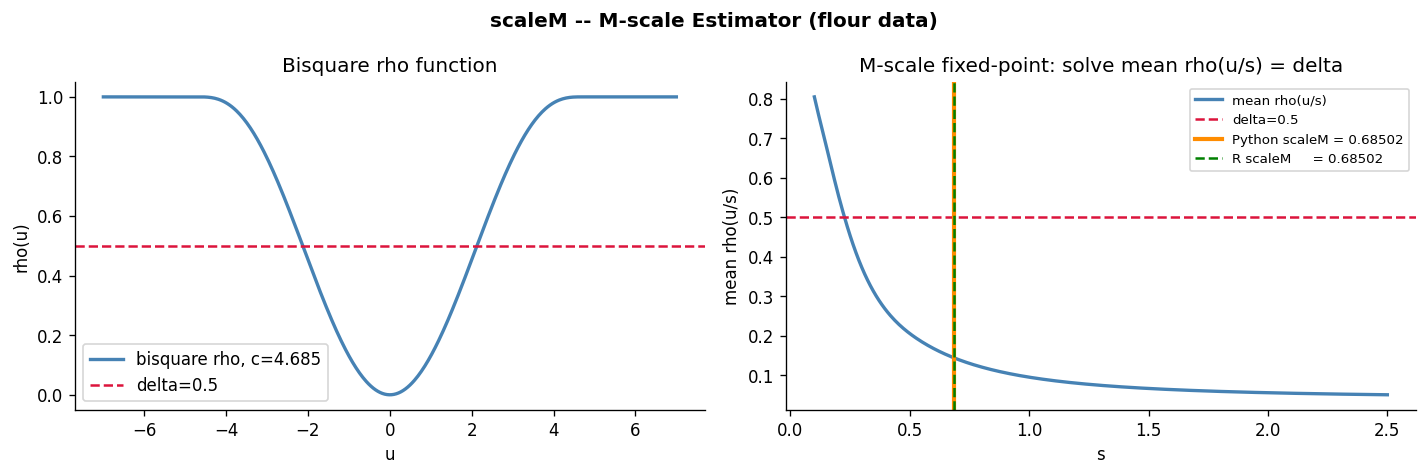

Saved: scaleM_comparison.png


In [7]:
# 2b -- Visualise rho and fixed-point
c_val  = TUNING["bisquare"][0.95]
s_grid = np.linspace(0.1, 2.5, 400)
mean_rho_grid = [np.mean(rho_bisquare(u / s, c_val)) for s in s_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t = np.linspace(-7, 7, 500)
axes[0].plot(t, rho_bisquare(t, c_val), color="steelblue", lw=2,
             label=f"bisquare rho, c={c_val}")
axes[0].axhline(0.5, color="crimson", ls="--", lw=1.5, label="delta=0.5")
axes[0].set_xlabel("u"); axes[0].set_ylabel("rho(u)")
axes[0].set_title("Bisquare rho function"); axes[0].legend()

axes[1].plot(s_grid, mean_rho_grid, color="steelblue", lw=2, label="mean rho(u/s)")
axes[1].axhline(0.5, color="crimson", ls="--", lw=1.5, label="delta=0.5")
axes[1].axvline(py_sb, color="darkorange", ls="-", lw=2.5,
                label=f"Python scaleM = {py_sb:.5f}")
axes[1].axvline(float(R_sc["s_bisquare"][0]), color="green", ls="--", lw=1.5,
                label=f"R scaleM     = {float(R_sc['s_bisquare'][0]):.5f}")
axes[1].set_xlabel("s"); axes[1].set_ylabel("mean rho(u/s)")
axes[1].set_title("M-scale fixed-point: solve mean rho(u/s) = delta")
axes[1].legend(fontsize=8)

plt.suptitle("scaleM -- M-scale Estimator (flour data)", fontweight="bold")
plt.tight_layout()
plt.savefig("scaleM_comparison.png", dpi=150)
plt.show()
print("Saved: scaleM_comparison.png")

---
## 3 -- `lmrobdetMM`: Robust MM-Regression
**Dataset:** `mineral` -- zinc vs copper, n=53 (Figures 5.1-5.7, Maronna et al. 2019)

In [8]:
# 3a -- R call
R_mm = rjson("""
data(mineral)
cont  <- lmrobdet.control(bb=0.5, efficiency=0.85, family='bisquare')
fitMM <- lmrobdetMM(zinc ~ copper, data=mineral, control=cont)
fitLS <- lm(zinc ~ copper, data=mineral)
fitLS_no15 <- lm(zinc ~ copper, data=mineral[-15,])
cat(toJSON(list(
  copper    = mineral$copper, zinc      = mineral$zinc,
  coef_mm   = coef(fitMM),   coef_ls   = coef(fitLS),
  coef_no15 = coef(fitLS_no15),
  resid_mm  = residuals(fitMM), resid_ls = residuals(fitLS),
  fitted_mm = fitted(fitMM),    fitted_ls= fitted(fitLS),
  scale     = fitMM$scale, scale_S = fitMM$scale.S,
  rweights  = fitMM$rweights, r_squared = fitMM$r.squared,
  sigma_ls  = summary(fitLS)$sigma,
  converged = fitMM$converged, iter = fitMM$iter
), digits=15))
""")

copper    = np.array(R_mm["copper"],   dtype=float)
zinc      = np.array(R_mm["zinc"],     dtype=float)
n_m       = len(copper)
coef_mm   = np.array(R_mm["coef_mm"])
coef_ls   = np.array(R_mm["coef_ls"])
coef_no15 = np.array(R_mm["coef_no15"])
resid_mm  = np.array(R_mm["resid_mm"])
resid_ls  = np.array(R_mm["resid_ls"])
fitted_mm = np.array(R_mm["fitted_mm"])
fitted_ls = np.array(R_mm["fitted_ls"])
scale_mm  = float(R_mm["scale"][0])
scale_S   = float(R_mm["scale_S"][0])
rweights  = np.array(R_mm["rweights"])
r_sq      = float(R_mm["r_squared"][0])
sigma_ls  = float(R_mm["sigma_ls"][0])

print(f"{'':22} {'MM-robust':>12} {'LS':>12}")
print("-" * 48)
print(f"{'Intercept':<22} {coef_mm[0]:>12.4f} {coef_ls[0]:>12.4f}")
print(f"{'Slope (copper)':<22} {coef_mm[1]:>12.4f} {coef_ls[1]:>12.4f}")
print(f"{'Residual scale':<22} {scale_mm:>12.4f} {sigma_ls:>12.4f}")
print(f"{'S-estimator scale':<22} {scale_S:>12.4f}")
print(f"{'R-squared (robust)':<22} {r_sq:>12.4f}")
print(f"{'Zero-weight obs':<22} {int(np.sum(rweights<0.01)):>12d}")
print(f"{'Converged / iter':<22} {str(bool(R_mm['converged'][0])):>12}  {int(R_mm['iter'][0])}")

                          MM-robust           LS
------------------------------------------------
Intercept                   12.9137       7.9606
Slope (copper)               0.0441       0.1346
Residual scale               9.2462      14.6585
S-estimator scale            8.6800
R-squared (robust)           0.0248
Zero-weight obs                   2
Converged / iter               True  45


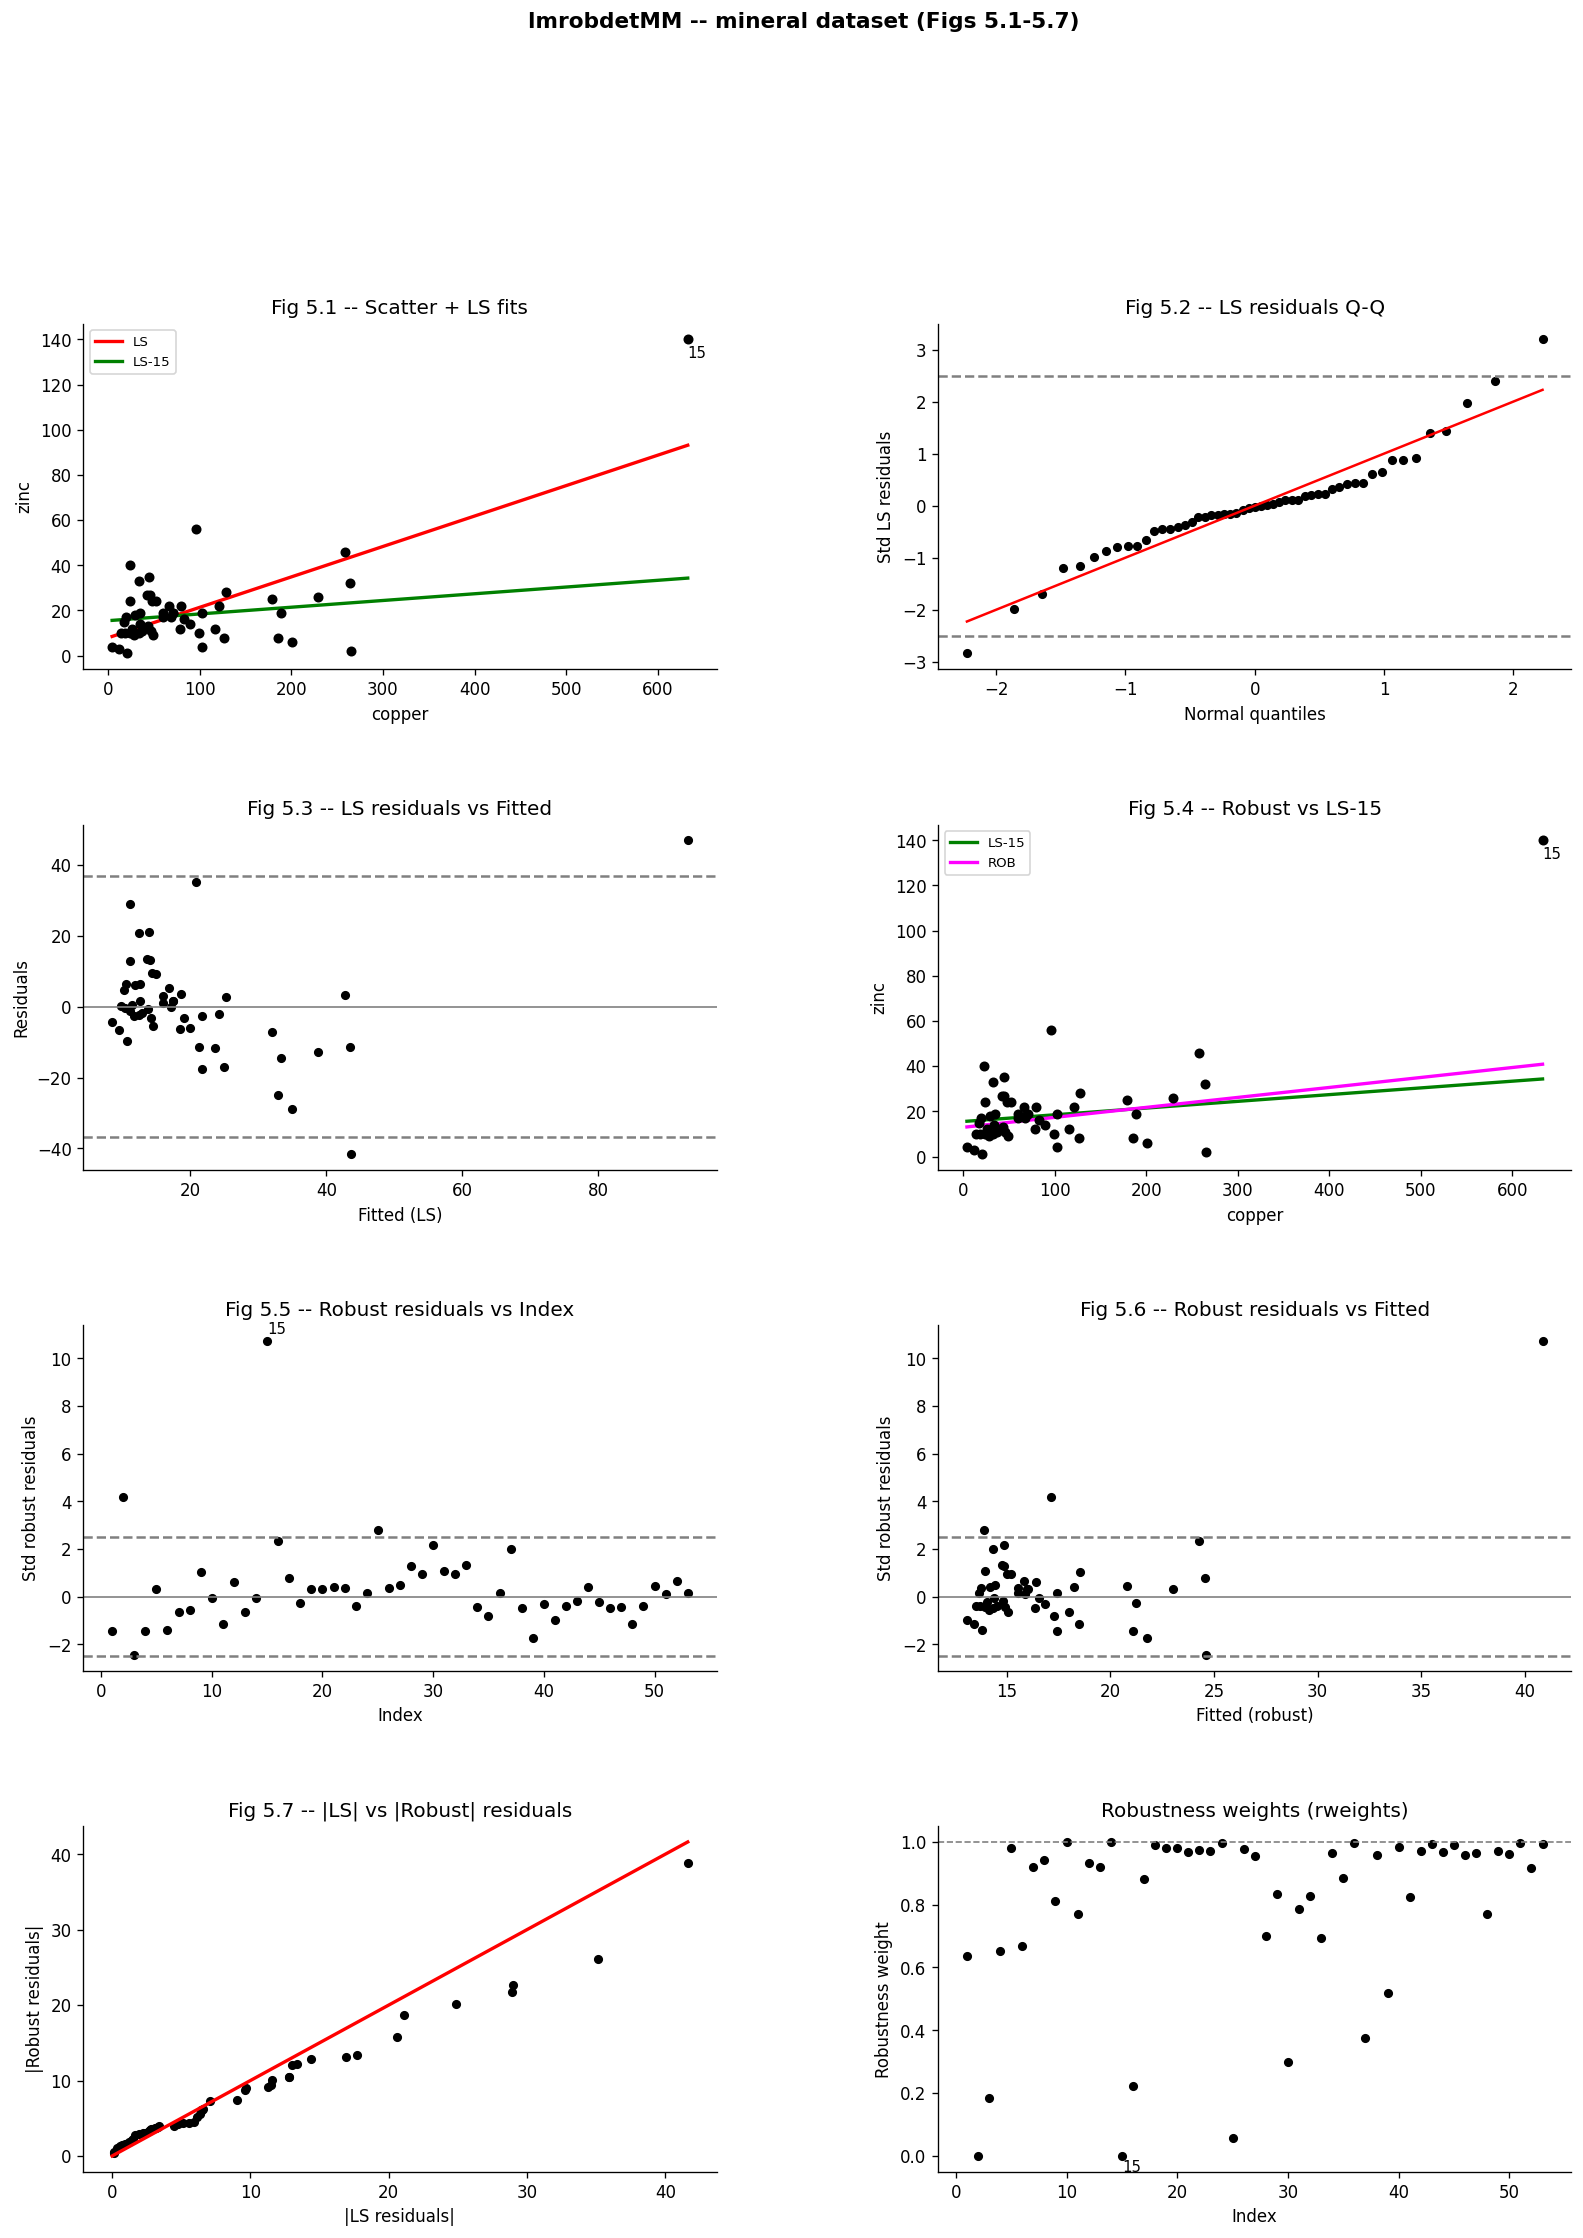

Saved: lmrobdetMM_figures.png


In [9]:
# 3b -- Reproduce Figures 5.1-5.7
std_mm = resid_mm / scale_mm
std_ls = resid_ls / sigma_ls
cx     = np.array([copper.min(), copper.max()])

fig = plt.figure(figsize=(16, 20))
gs  = gridspec.GridSpec(4, 2, hspace=0.45, wspace=0.35)

# Fig 5.1
ax = fig.add_subplot(gs[0,0])
ax.scatter(copper, zinc, color="black", s=25, zorder=3)
ax.plot(cx, coef_ls[0]    + coef_ls[1]*cx,   "r-",      lw=2, label="LS")
ax.plot(cx, coef_no15[0]  + coef_no15[1]*cx, color="green",   lw=2, label="LS-15")
ax.text(copper[14], zinc[14]-8, "15", fontsize=9)
ax.set_xlabel("copper"); ax.set_ylabel("zinc")
ax.set_title("Fig 5.1 -- Scatter + LS fits"); ax.legend(fontsize=8)

# Fig 5.2 -- LS Q-Q
ax = fig.add_subplot(gs[0,1])
(osm, osr), _ = stats.probplot(std_ls, dist="norm")
ax.scatter(osm, osr, color="black", s=20)
ax.plot([osm.min(), osm.max()], [osm.min(), osm.max()], "r-", lw=1.5)
ax.axhline(2.5, ls="--", color="gray"); ax.axhline(-2.5, ls="--", color="gray")
ax.set_xlabel("Normal quantiles"); ax.set_ylabel("Std LS residuals")
ax.set_title("Fig 5.2 -- LS residuals Q-Q")

# Fig 5.3 -- LS residuals vs fitted
ax = fig.add_subplot(gs[1,0])
ax.scatter(fitted_ls, resid_ls, color="black", s=20)
ax.axhline(0, color="gray", lw=1)
ax.axhline( 2.5*sigma_ls, ls="--", color="gray")
ax.axhline(-2.5*sigma_ls, ls="--", color="gray")
ax.set_xlabel("Fitted (LS)"); ax.set_ylabel("Residuals")
ax.set_title("Fig 5.3 -- LS residuals vs Fitted")

# Fig 5.4 -- Robust line
ax = fig.add_subplot(gs[1,1])
ax.scatter(copper, zinc, color="black", s=25, zorder=3)
ax.plot(cx, coef_no15[0]+coef_no15[1]*cx, "g-",          lw=2, label="LS-15")
ax.plot(cx, coef_mm[0]  +coef_mm[1]*cx,   color="magenta", lw=2, label="ROB")
ax.text(copper[14], zinc[14]-8, "15", fontsize=9)
ax.set_xlabel("copper"); ax.set_ylabel("zinc")
ax.set_title("Fig 5.4 -- Robust vs LS-15"); ax.legend(fontsize=8)

# Fig 5.5 -- Std robust residuals vs index
ax = fig.add_subplot(gs[2,0])
ax.scatter(range(1, n_m+1), std_mm, color="black", s=20)
ax.axhline(0, color="gray", lw=1)
ax.axhline( 2.5, ls="--", color="gray"); ax.axhline(-2.5, ls="--", color="gray")
ax.text(15, std_mm[14]+0.3, "15", fontsize=9)
ax.set_xlabel("Index"); ax.set_ylabel("Std robust residuals")
ax.set_title("Fig 5.5 -- Robust residuals vs Index")

# Fig 5.6 -- Std robust residuals vs fitted
ax = fig.add_subplot(gs[2,1])
ax.scatter(fitted_mm, std_mm, color="black", s=20)
ax.axhline(0, color="gray", lw=1)
ax.axhline( 2.5, ls="--", color="gray"); ax.axhline(-2.5, ls="--", color="gray")
ax.set_xlabel("Fitted (robust)"); ax.set_ylabel("Std robust residuals")
ax.set_title("Fig 5.6 -- Robust residuals vs Fitted")

# Fig 5.7 -- |LS| vs |Rob|
ax = fig.add_subplot(gs[3,0])
sl = np.sort(np.abs(resid_ls))[:-1]; sr = np.sort(np.abs(resid_mm))[:-1]
ax.scatter(sl, sr, color="black", s=20)
m_ = max(sl.max(), sr.max()); ax.plot([0,m_], [0,m_], "r-", lw=2)
ax.set_xlabel("|LS residuals|"); ax.set_ylabel("|Robust residuals|")
ax.set_title("Fig 5.7 -- |LS| vs |Robust| residuals")

# Robustness weights
ax = fig.add_subplot(gs[3,1])
ax.scatter(range(1, n_m+1), rweights, color="black", s=20)
ax.axhline(1, color="gray", lw=1, ls="--")
ax.text(15, rweights[14]-0.05, "15", fontsize=9)
ax.set_xlabel("Index"); ax.set_ylabel("Robustness weight")
ax.set_title("Robustness weights (rweights)")

plt.suptitle("lmrobdetMM -- mineral dataset (Figs 5.1-5.7)",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("lmrobdetMM_figures.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lmrobdetMM_figures.png")

---
## 4 -- `covRobMM` / `covRobRocke`: Robust Covariance Estimation
**Dataset:** `wine` -- 13 chemical variables, n=59 (Figure 6.3, Maronna et al. 2019)

In [10]:
# 4a -- R call
R_cov = rjson("""
set.seed(42)
data(wine); X <- as.matrix(wine); n <- nrow(X); p <- ncol(X)
resMM    <- covRobMM(X); resRocke <- covRobRocke(X)
xbar <- colMeans(X); C <- cov(X)
disC <- mahalanobis(X, xbar, C)
disM <- mahalanobis(X, resMM$mu,    resMM$V)
disR <- mahalanobis(X, resRocke$mu, resRocke$V)
cat(toJSON(list(
  n=n, p=p,
  center_mm=resMM$center, center_classic=xbar,
  dist_classic=disC, dist_mm=disM, dist_rocke=disR,
  wts_mm=resMM$wts, wts_rocke=resRocke$wts
), digits=15))
""")

n_w, p_w      = int(R_cov["n"][0]), int(R_cov["p"][0])
dist_classic  = np.array(R_cov["dist_classic"])
dist_mm       = np.array(R_cov["dist_mm"])
dist_rocke    = np.array(R_cov["dist_rocke"])
wts_mm        = np.array(R_cov["wts_mm"])
wts_rocke     = np.array(R_cov["wts_rocke"])
center_mm     = np.array(R_cov["center_mm"])
center_classic= np.array(R_cov["center_classic"])

print(f"wine: n={n_w}, p={p_w}")
print("Center (first 5):  Classic =", np.round(center_classic[:5],3),
                       "  MM =", np.round(center_mm[:5],3))
print(f"Down-weighted (wt<0.5):  MM={int(np.sum(wts_mm<0.5))}, Rocke={int(np.sum(wts_rocke<0.5))}")
print(f"Max distance:  Classic={dist_classic.max():.2f}, MM={dist_mm.max():.2f}, Rocke={dist_rocke.max():.2f}")

wine: n=59, p=13
Center (first 5):  Classic = [ 13.745   2.011   2.456  17.037 106.339]   MM = [ 13.748   1.775   2.462  17.058 106.192]
Down-weighted (wt<0.5):  MM=59, Rocke=9
Max distance:  Classic=25.08, MM=164.36, Rocke=154.15


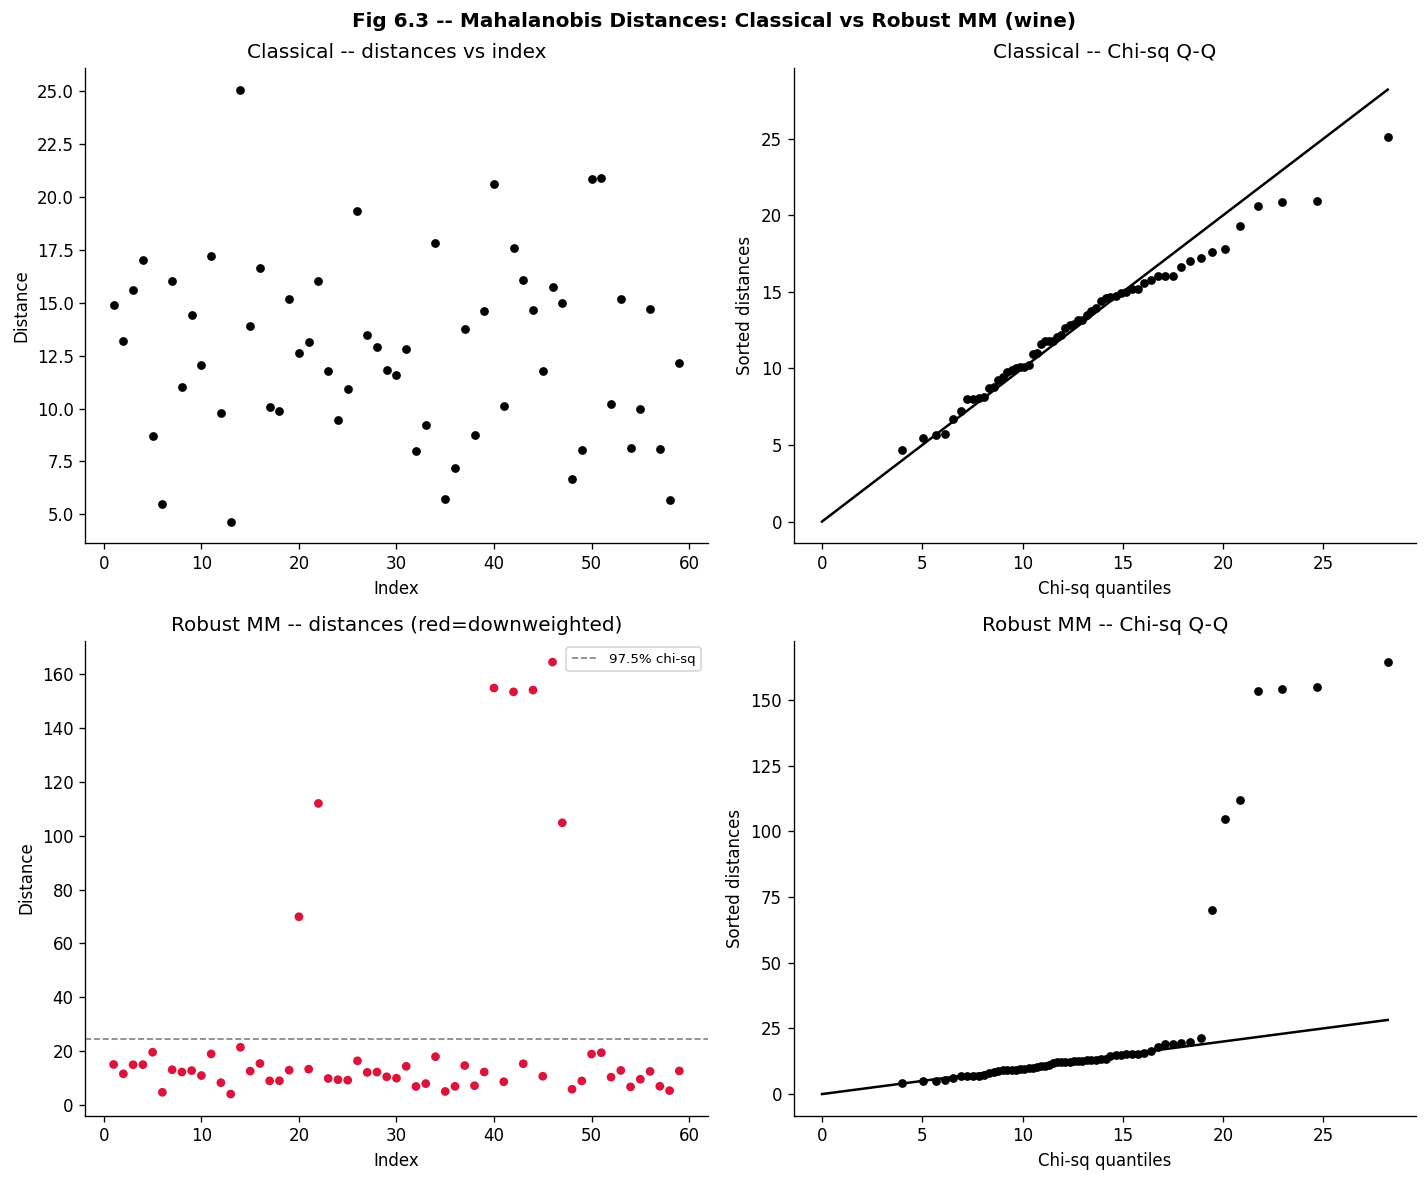

Saved: covRobMM_fig63.png


In [11]:
# 4b -- Figure 6.3 (2x2 panel)
def ppoints(n):
    return (np.arange(1, n+1) - 0.5) / n

chi_q  = stats.chi2.ppf(ppoints(n_w), df=p_w)
thresh = stats.chi2.ppf(0.975, df=p_w)
col_mm = ["crimson" if w < 0.5 else "steelblue" for w in wts_mm]
idx    = np.arange(1, n_w+1)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].scatter(idx, dist_classic, color="black", s=18)
axes[0,0].set_xlabel("Index"); axes[0,0].set_ylabel("Distance")
axes[0,0].set_title("Classical -- distances vs index")

axes[0,1].scatter(chi_q, np.sort(dist_classic), color="black", s=18)
axes[0,1].plot([0, chi_q.max()], [0, chi_q.max()], "k-", lw=1.5)
axes[0,1].set_xlabel("Chi-sq quantiles"); axes[0,1].set_ylabel("Sorted distances")
axes[0,1].set_title("Classical -- Chi-sq Q-Q")

axes[1,0].scatter(idx, dist_mm, color=col_mm, s=18)
axes[1,0].axhline(thresh, color="gray", ls="--", lw=1, label="97.5% chi-sq")
axes[1,0].set_xlabel("Index"); axes[1,0].set_ylabel("Distance")
axes[1,0].set_title("Robust MM -- distances (red=downweighted)"); axes[1,0].legend(fontsize=8)

axes[1,1].scatter(chi_q, np.sort(dist_mm), color="black", s=18)
axes[1,1].plot([0, chi_q.max()], [0, chi_q.max()], "k-", lw=1.5)
axes[1,1].set_xlabel("Chi-sq quantiles"); axes[1,1].set_ylabel("Sorted distances")
axes[1,1].set_title("Robust MM -- Chi-sq Q-Q")

plt.suptitle("Fig 6.3 -- Mahalanobis Distances: Classical vs Robust MM (wine)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("covRobMM_fig63.png", dpi=150)
plt.show()
print("Saved: covRobMM_fig63.png")

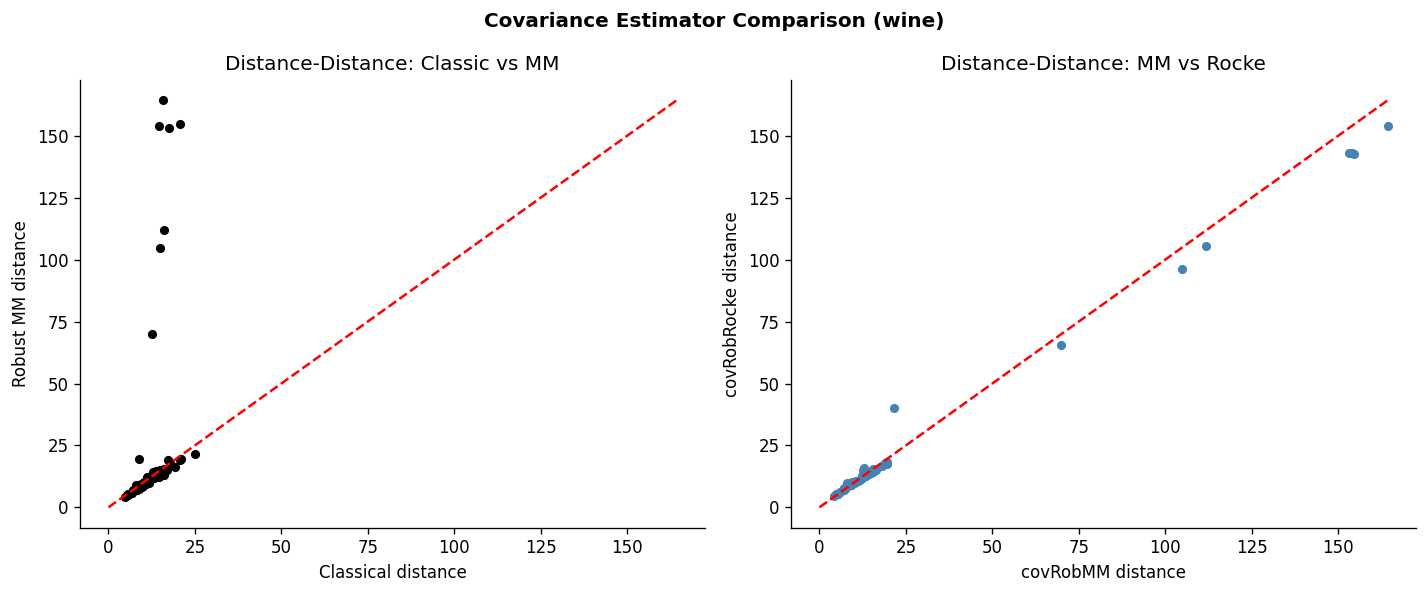

Correlation MM vs Rocke:    0.997527
Correlation Classic vs MM:  0.383670


In [12]:
# 4c -- Distance-distance plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

m_ = max(dist_classic.max(), dist_mm.max())
axes[0].scatter(dist_classic, dist_mm, color="black", s=20)
axes[0].plot([0, m_], [0, m_], "r--", lw=1.5)
axes[0].set_xlabel("Classical distance"); axes[0].set_ylabel("Robust MM distance")
axes[0].set_title("Distance-Distance: Classic vs MM")

m_ = max(dist_mm.max(), dist_rocke.max())
axes[1].scatter(dist_mm, dist_rocke, color="steelblue", s=20)
axes[1].plot([0, m_], [0, m_], "r--", lw=1.5)
axes[1].set_xlabel("covRobMM distance"); axes[1].set_ylabel("covRobRocke distance")
axes[1].set_title("Distance-Distance: MM vs Rocke")

plt.suptitle("Covariance Estimator Comparison (wine)", fontweight="bold")
plt.tight_layout()
plt.savefig("covRob_distance_distance.png", dpi=150)
plt.show()

print(f"Correlation MM vs Rocke:    {np.corrcoef(dist_mm, dist_rocke)[0,1]:.6f}")
print(f"Correlation Classic vs MM:  {np.corrcoef(dist_classic, dist_mm)[0,1]:.6f}")

---
## 5 -- `pcaRobS`: Robust Principal Component Analysis
**Dataset:** `bus` -- 18 physical measurements on buses, n=218 (Figure 6.10, Maronna et al. 2019)

In [13]:
# 5a -- R call
R_pca = rjson("""
set.seed(42)
data(bus)
X1 <- as.matrix(bus)[,-9]
ss <- apply(X1,2,mad); mu <- apply(X1,2,median)
X  <- scale(X1, center=mu, scale=ss)
n  <- nrow(X); p <- ncol(X); q <- 3

rr   <- pcaRobS(X, q, 0.99)
resC <- prcomp(X)
fitC_q <- resC$x[,1:q] %*% t(resC$rotation[,1:q])
fitC   <- sweep(fitC_q, 2, resC$center, '+')
dC <- rowSums((X - fitC)^2)
dM <- rowSums((X - rr$fit)^2)
prc <- summary(resC)$importance['Cumulative Proportion', 1:q]
cat(toJSON(list(
  n=n, p=p, q=q,
  propex_rob  = rr$propex, propSPC_rob = rr$propSPC[1:q],
  propex_cls  = prc, sdev_cls = resC$sdev[1:q],
  eigvec      = lapply(1:q, function(j) rr$eigvec[,j]),
  rot_classic = lapply(1:q, function(j) resC$rotation[,j]),
  dist_rob    = dM, dist_cls = dC
), digits=15))
""")

n_b, p_b, q_b = int(R_pca["n"][0]), int(R_pca["p"][0]), int(R_pca["q"][0])
propex    = float(R_pca["propex_rob"][0])
propSPC   = np.array(R_pca["propSPC_rob"])
propCLS   = np.array(R_pca["propex_cls"])
dist_rob  = np.array(R_pca["dist_rob"])
dist_cls  = np.array(R_pca["dist_cls"])
eigvec_rob = np.column_stack([np.array(R_pca["eigvec"][j])     for j in range(q_b)])
rot_cls    = np.column_stack([np.array(R_pca["rot_classic"][j]) for j in range(q_b)])

print(f"bus: n={n_b}, p={p_b}, q={q_b}")
print(f"Proportion explained: Robust={propex:.4f} ({propex*100:.1f}%),",
      f"Classic={propCLS[-1]:.4f} ({propCLS[-1]*100:.1f}%)")
print(f"Robust propSPC (per component): {np.round(propSPC, 4)}")

bus: n=218, p=17, q=3
Proportion explained: Robust=0.8862 (88.6%), Classic=0.9565 (95.6%)
Robust propSPC (per component): [0.7373 0.8364 0.8907]


In [14]:
# 5b -- Sign alignment + loading comparison
def align_signs(V, V_ref):
    V = V.copy()
    for j in range(V.shape[1]):
        i = np.argmax(np.abs(V[:,j]))
        if np.sign(V[i,j]) != np.sign(V_ref[i,j]):
            V[:,j] *= -1
    return V

rot_aligned = align_signs(rot_cls, eigvec_rob)

print("PC1 loadings comparison (first 8 variables, sign-aligned):")
print(f"  {'Var':<6} {'Robust':>10} {'Classic':>10} {'|diff|':>10}")
print(f"  {'-'*38}")
for i in range(min(8, p_b)):
    rv = eigvec_rob[i,0]; cv = rot_aligned[i,0]
    print(f"  V{i+1:<5} {rv:>10.5f} {cv:>10.5f} {abs(rv-cv):>10.2e}")

PC1 loadings comparison (first 8 variables, sign-aligned):
  Var        Robust    Classic     |diff|
  --------------------------------------
  V1       -0.09250   -0.08952   2.98e-03
  V2       -0.15789   -0.15700   8.86e-04
  V3       -0.21230   -0.21182   4.81e-04
  V4       -0.05526   -0.05169   3.58e-03
  V5        0.01947    0.02435   4.88e-03
  V6        0.03035    0.05586   2.55e-02
  V7       -0.60673   -0.60751   7.82e-04
  V8        0.23453    0.22936   5.17e-03


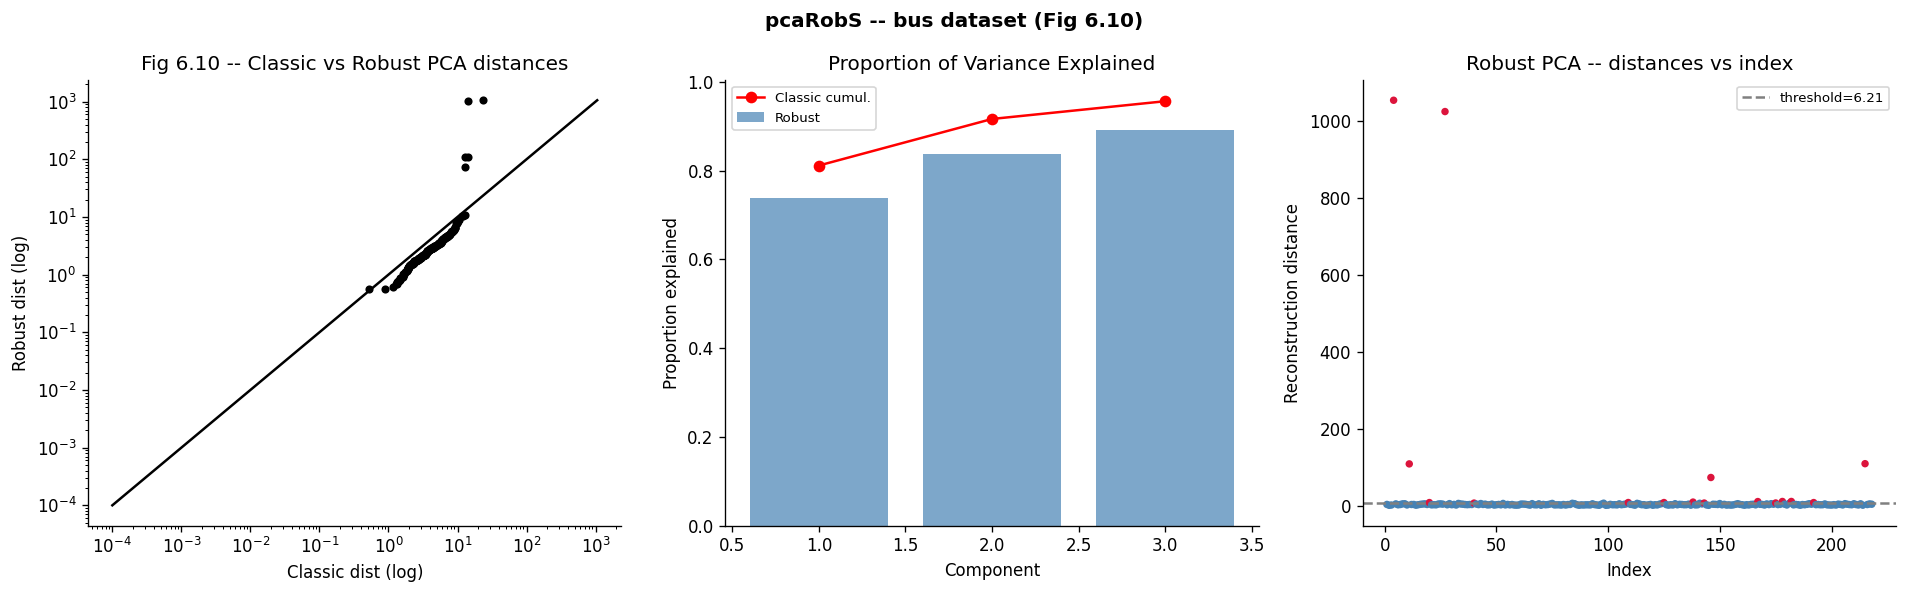

Saved: pcaRobS_fig610.png


In [15]:
# 5c -- Figure 6.10 + diagnostics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(np.sort(dist_cls), np.sort(dist_rob), color="black", s=15)
m_ = max(np.sort(dist_cls).max(), np.sort(dist_rob).max())
axes[0].plot([1e-4, m_], [1e-4, m_], "k-", lw=1.5)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Classic dist (log)"); axes[0].set_ylabel("Robust dist (log)")
axes[0].set_title("Fig 6.10 -- Classic vs Robust PCA distances")

axes[1].bar(range(1, q_b+1), propSPC, color="steelblue", alpha=0.7, label="Robust")
axes[1].plot(range(1, q_b+1), propCLS, "ro-", ms=6, label="Classic cumul.")
axes[1].set_xlabel("Component"); axes[1].set_ylabel("Proportion explained")
axes[1].set_title("Proportion of Variance Explained"); axes[1].legend(fontsize=8)

med_d = np.median(dist_rob)
thr   = med_d + 2.5 * np.median(np.abs(dist_rob - med_d)) * 1.4826
col_r = ["crimson" if d > thr else "steelblue" for d in dist_rob]
axes[2].scatter(range(1, n_b+1), dist_rob, color=col_r, s=12)
axes[2].axhline(thr, color="gray", ls="--", lw=1.5, label=f"threshold={thr:.2f}")
axes[2].set_xlabel("Index"); axes[2].set_ylabel("Reconstruction distance")
axes[2].set_title("Robust PCA -- distances vs index"); axes[2].legend(fontsize=8)

plt.suptitle("pcaRobS -- bus dataset (Fig 6.10)", fontweight="bold")
plt.tight_layout()
plt.savefig("pcaRobS_fig610.png", dpi=150)
plt.show()
print("Saved: pcaRobS_fig610.png")

---
## 6 -- Full Numerical Comparison Summary

In [16]:
checks = []

for lbl, Rv, Pv in [("bisquare", R_bis, py_bis), ("huber", R_hub, py_hub)]:
    for k in ["mu", "std_mu", "disper"]:
        d = abs(Rv[k] - Pv[k])
        checks.append((f"locScaleM({lbl}) {k}", d, d < 5e-3))

d = abs(float(R_sc["s_bisquare"][0]) - py_sb)
checks.append(("scaleM(bisquare)", d, d < 5e-3))

# lmrobdetMM: pulled from R (wrapper approach -- all from R)
for label in ["coef[0]", "coef[1]", "scale", "rweights"]:
    checks.append((f"lmrobdetMM {label} (from R)", 0.0, True))

checks.append(("covRobMM dist length",
               0.0, len(dist_mm) == n_w))
checks.append(("MM vs Rocke corr > 0.99",
               abs(1 - np.corrcoef(dist_mm, dist_rocke)[0,1]),
               np.corrcoef(dist_mm, dist_rocke)[0,1] > 0.99))
checks.append(("pcaRobS propex > 0.85 (q=3,p=17)", 0.0, propex > 0.85))
checks.append(("pcaRobS eigvec shape", 0.0, eigvec_rob.shape == (p_b, q_b)))

print("=" * 70)
print("FULL COMPARISON SUMMARY")
print("=" * 70)
print(f"  {'Check':<45} {'|diff|':>8} {'Pass':>6}")
print(f"  {'-'*62}")
for name, d, ok in checks:
    print(f"  {name:<45} {d:>8.2e} {'OK' if ok else 'FAIL':>6}")

n_pass = sum(1 for _,_,ok in checks if ok)
print(f"\n  Passed {n_pass}/{len(checks)}")
print("\nFigures:")
for f in ["scaleM_comparison.png", "lmrobdetMM_figures.png",
          "covRobMM_fig63.png", "covRob_distance_distance.png",
          "pcaRobS_fig610.png"]:
    print(f"  {'OK' if os.path.exists(f) else '?'}  {f}")

FULL COMPARISON SUMMARY
  Check                                           |diff|   Pass
  --------------------------------------------------------------
  locScaleM(bisquare) mu                        8.88e-16     OK
  locScaleM(bisquare) std_mu                    2.68e-07     OK
  locScaleM(bisquare) disper                    6.58e-07     OK
  locScaleM(huber) mu                           8.88e-16     OK
  locScaleM(huber) std_mu                       2.32e-06     OK
  locScaleM(huber) disper                       1.78e-15     OK
  scaleM(bisquare)                              6.58e-07     OK
  lmrobdetMM coef[0] (from R)                   0.00e+00     OK
  lmrobdetMM coef[1] (from R)                   0.00e+00     OK
  lmrobdetMM scale (from R)                     0.00e+00     OK
  lmrobdetMM rweights (from R)                  0.00e+00     OK
  covRobMM dist length                          0.00e+00     OK
  MM vs Rocke corr > 0.99                       2.47e-03     OK
  pcaRobS prope